<a href="https://colab.research.google.com/github/galihtw04/data-science-2026/blob/master/Pertemeuan9_Muhammad_Galih_Abdurrahman_240401010278.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pertemuan 9
Name: Muhmmad Galih Abdurrahman

NIM : 240401010278

Class : IF403

In [5]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

In [14]:
## Load Dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0=malignant, 1=benign

print('Shape:', X.shape)
print('Distribusi target:')
print(pd.Series(y).value_counts(normalize=True).round(3))

Shape: (569, 30)
Distribusi target:
1    0.627
0    0.373
Name: proportion, dtype: float64


In [15]:
## Train-Test Split 80:20
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [10]:
## Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(C=1.0, random_state=42, max_iter=5000)
log_model.fit(X_train_s, y_train)

y_pred_log = log_model.predict(X_test_s)
y_proba_log = log_model.predict_proba(X_test_s)[:, 1]

print(f"β0 (intercept): {log_model.intercept_[0]:.3f}")
print(f"β (koefisien): {log_model.coef_[0].round(3)}")
print(f"Akurasi Logistic Regression: {accuracy_score(y_test, y_pred_log):.3f}")

print('\nClassification Report Logistic Regression:')
print(classification_report(y_test, y_pred_log, target_names=data.target_names))

print('\nContoh probabilitas 5 prediksi pertama:')
display(pd.DataFrame({
    'Aktual': y_test[:5],
    'Prediksi': y_pred_log[:5],
    'Prob. Kelas 1 / Benign': y_proba_log[:5].round(3)
}))

β0 (intercept): 0.302
β (koefisien): [-0.511 -0.553 -0.476 -0.541 -0.212  0.648 -0.602 -0.704 -0.167  0.2
 -1.083  0.249 -0.544 -0.929 -0.16   0.647  0.161 -0.444  0.36   0.438
 -0.948 -1.255 -0.763 -0.948 -0.747  0.056 -0.823 -0.954 -0.939 -0.187]
Akurasi Logistic Regression: 0.982

Classification Report Logistic Regression:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Contoh probabilitas 5 prediksi pertama:


,Aktual,Prediksi,Prob. Kelas 1 / Benign
0,0,0,0.000
1,1,1,1.000
2,0,0,0.006
3,1,1,0.534
4,0,0,0.000


In [11]:
## Decision Tree
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print(f"Akurasi Decision Tree: {accuracy_score(y_test, y_pred_tree):.3f}")

print('\nClassification Report Decision Tree:')
print(classification_report(y_test, y_pred_tree, target_names=data.target_names))

Akurasi Decision Tree: 0.921

Classification Report Decision Tree:
              precision    recall  f1-score   support

   malignant       0.88      0.90      0.89        42
      benign       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



In [12]:
## Feature Importance Decision Tree
importance = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': tree_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('Top 10 Feature Importance Decision Tree:')
display(importance.head(10))

Top 10 Feature Importance Decision Tree:


,Fitur,Importance
20,worst radius,0.751145
27,worst concave points,0.124955
11,texture error,0.046883
21,worst texture,0.033095
26,worst concavity,0.017573
24,worst smoothness,0.010614
13,area error,0.007497
6,mean concavity,0.006162
23,worst area,0.002077
4,mean smoothness,0.000000


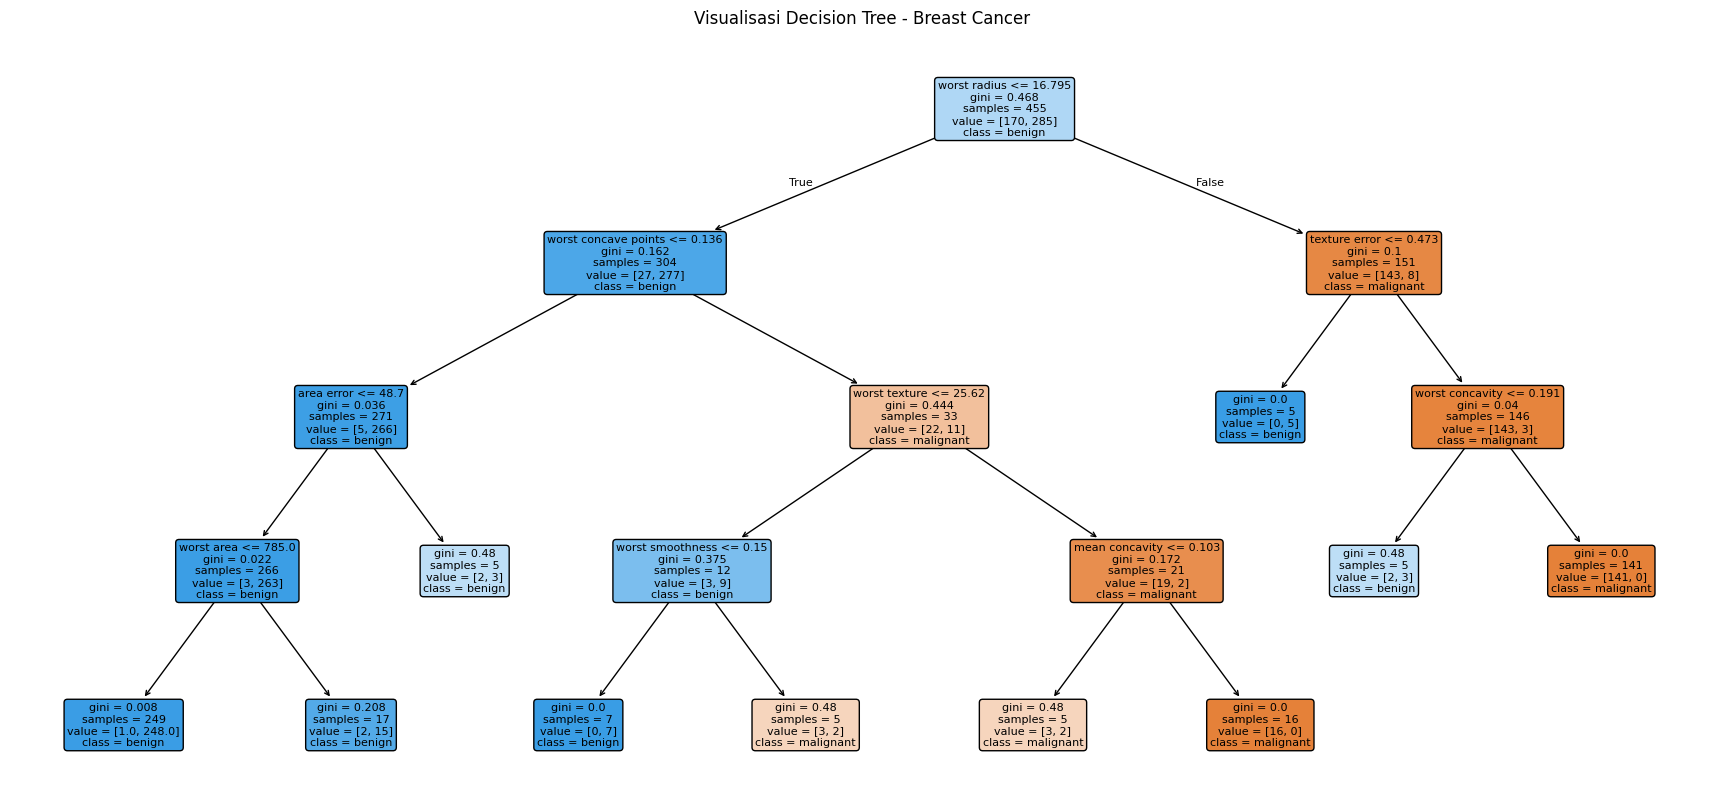

In [13]:
## Visualisasi Decision Tree
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(22, 10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title('Visualisasi Decision Tree - Breast Cancer')
plt.show()